In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings
import torch
import torch.nn as nn
import h5py
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm


warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['figure.dpi'] = 200 # plots quality


path='/content/drive/Shareddrives/XAI Project Shared Drive'

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
X = np.load(f'{path}/X_100hz.npy')
df_ptbxl = pd.read_csv(f'{path}/ptbxl_processed_metadata.csv', index_col='ecg_id')
df_ptbxl['scp_codes'] = df_ptbxl['scp_codes'].apply(lambda x: ast.literal_eval(x))

print(f"Signal Data Shape [Samples, Time, Leads]: {X.shape}")
print(f"Metadata Shape: {df_ptbxl.shape}")


Signal Data Shape [Samples, Time, Leads]: (21799, 1000, 12)
Metadata Shape: (21799, 27)


In [ ]:
agg_df = pd.read_csv(f'{path}/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1]


superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def aggregate_diagnostic(y_dict):
    new_dict = {}

    for sc in superclasses:
        new_dict[sc]=0

    for key, val in y_dict.items():
        if key in agg_df.index:
            sc = agg_df.loc[key]['diagnostic_class']
            new_dict[sc]=max(new_dict[sc], val/100)

    lst = []
    for sc in superclasses:
        if new_dict[sc] >= 0.5:
            lst.append(1)
        else:
            lst.append(0)
    return lst

df_ptbxl['diagnostic_superclass'] = df_ptbxl.scp_codes.apply(aggregate_diagnostic)

In [ ]:
Y = np.array(df_ptbxl['diagnostic_superclass'].to_list())

train_mask = df_ptbxl['strat_fold'] <= 8
val_mask = df_ptbxl['strat_fold'] == 9
test_mask = df_ptbxl['strat_fold'] == 10

X_train, y_train = X[train_mask], Y[train_mask]
X_val, y_val     = X[val_mask], Y[val_mask]
X_test, y_test   = X[test_mask], Y[test_mask]

# Model 1: 2D CNN + STFT Spectrograms

# Model 2: 2D-CNN-LSTM

In [ ]:
!pip install -q torch numpy pandas scikit-learn shap lime captum

  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.metrics import roc_auc_score, f1_score
import shap
from lime import lime_image
from captum.attr import IntegratedGradients, LayerGradCam
from tqdm import tqdm

class PyTorchCWT(nn.Module):
    def __init__(self, num_scales=40):
        super().__init__()
        self.num_scales = num_scales

    def forward(self, x):
        B, C, L = x.shape
        out = []
        for i in range(1, self.num_scales + 1):
            # Scale the wavelet window size progressively
            window_size = i * 4
            t = torch.linspace(-5, 5, window_size, device=x.device).view(1, 1, -1)

            # Morlet Wavelet
            wavelet = torch.exp(-0.5 * t**2) * torch.cos(5 * t)
            wavelet = wavelet.repeat(C, 1, 1)

            # Apply 1D Convolution
            pad = window_size // 2
            filtered = F.conv1d(x, wavelet, padding=pad, groups=C)

            # Trim padding to match original sequence length
            out.append(filtered[:, :, :L])

        scalogram = torch.stack(out, dim=2) # Shape: (B, C, Scales, L)

        # Take the absolute magnitude (CRUCIAL for smooth scalograms!)
        scalogram = torch.abs(scalogram)

        return F.interpolate(scalogram, size=(227, 227), mode='bilinear', align_corners=False)
class CNN_LSTM_Classifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(12, 64, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.BatchNorm2d(64), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=1, stride=1, padding=0), nn.ReLU(), nn.BatchNorm2d(128), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1), nn.ReLU(), nn.BatchNorm2d(256), nn.MaxPool2d(2)
        )
        self.lstm = nn.LSTM(input_size=28*256, hidden_size=200, batch_first=True)
        self.fc = nn.Sequential(nn.Dropout(0.5), nn.Linear(200, num_classes))

    def forward(self, x):
        x = self.cnn(x)
        B, C, H, W = x.shape
        x = x.view(B, W, H * C)
        _, (hn, _) = self.lstm(x)
        return self.fc(hn[-1])

class HybridArrhythmiaModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.cwt = PyTorchCWT(num_scales=32)
        self.classifier = CNN_LSTM_Classifier(num_classes)

    def forward(self, x):
        return self.classifier(self.cwt(x))

class MemoryDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).transpose(1, 2)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [54]:
def train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test, epochs=10, batch_size=32):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    num_classes = y_train.shape[1]

    train_loader = DataLoader(MemoryDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(MemoryDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

    model = HybridArrhythmiaModel(num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.BCEWithLogitsLoss()

    for epoch in tqdm(range(epochs)):
        model.train()
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for x, y in val_loader:
                out = model(x.to(device))
                preds.append(torch.sigmoid(out).cpu().numpy())
                targets.append(y.numpy())

        preds = np.vstack(preds)
        targets = np.vstack(targets)
        val_auc = roc_auc_score(targets, preds, average='macro')
        val_f1 = f1_score(targets, (preds > 0.5).astype(int), average='macro')
        print(f"Epoch {epoch+1}/{epochs} | Val AUC: {val_auc:.4f} | Val F1: {val_f1:.4f}")

    return model, MemoryDataset(X_test, y_test)

model, test_dataset = train_and_evaluate(X_train, y_train, X_val, y_val, X_test, y_test)

 10%|█         | 1/10 [02:07<19:03, 127.10s/it]

Epoch 1/10 | Val AUC: 0.8604 | Val F1: 0.4038


 20%|██        | 2/10 [04:12<16:50, 126.36s/it]

Epoch 2/10 | Val AUC: 0.8717 | Val F1: 0.5348


 30%|███       | 3/10 [06:19<14:43, 126.28s/it]

...

Epoch 8/10 | Val AUC: 0.8860 | Val F1: 0.6052


 90%|█████████ | 9/10 [18:56<02:06, 126.06s/it]

Epoch 9/10 | Val AUC: 0.8821 | Val F1: 0.6056


100%|██████████| 10/10 [21:02<00:00, 126.21s/it]

Epoch 10/10 | Val AUC: 0.8850 | Val F1: 0.5693


In [55]:
def apply_xai(model, test_dataset):
    device = next(model.parameters()).device
    model.eval()

    torch.backends.cudnn.enabled = False

    sample_1d, target = test_dataset[0]
    sample_1d = sample_1d.unsqueeze(0).to(device)
    target_class = torch.argmax(target).item()

    with torch.no_grad():
        img_2d = model.cwt(sample_1d)
        bg_1d = torch.stack([test_dataset[i][0] for i in range(1, min(11, len(test_dataset)))]).to(device)
        bg_2d = model.cwt(bg_1d)

    # 1. SHAP
    explainer_shap = shap.GradientExplainer(model.classifier, bg_2d)
    shap_values = explainer_shap.shap_values(img_2d)

    # 2. Integrated Gradients
    ig = IntegratedGradients(model.classifier)
    attr_ig = ig.attribute(img_2d, target=target_class)

    # 3. Grad-CAM
    layer_gc = LayerGradCam(model.classifier, model.classifier.cnn[4])
    attr_gc = layer_gc.attribute(img_2d, target=target_class)

    # 4. LIME
    def lime_predict_fn(images):
        imgs = torch.tensor(images).permute(0, 3, 1, 2).float().to(device)
        with torch.no_grad():
            return model.classifier(imgs).cpu().numpy()

    lime_explainer = lime_image.LimeImageExplainer()
    img_hwc = img_2d[0].permute(1, 2, 0).cpu().numpy()

    # Take first 3 channels for LIME visualization constraints if 12 channels exist
    img_hwc_rgb = img_hwc[:, :, :3] if img_hwc.shape[-1] > 3 else img_hwc

    lime_explanation = lime_explainer.explain_instance(
        img_hwc_rgb,
        lambda x: lime_predict_fn(np.repeat(x[:, :, :], img_hwc.shape[-1] // 3, axis=-1) if img_hwc.shape[-1] == 12 else x),
        top_labels=1, hide_color=0, num_samples=100
    )

    return img_2d, shap_values, attr_ig, attr_gc, lime_explanation


img_2d, shap_vals, ig_attr, gc_attr, lime_exp = apply_xai(model, test_dataset)

  0%|          | 0/100 [00:00<?, ?it/s]

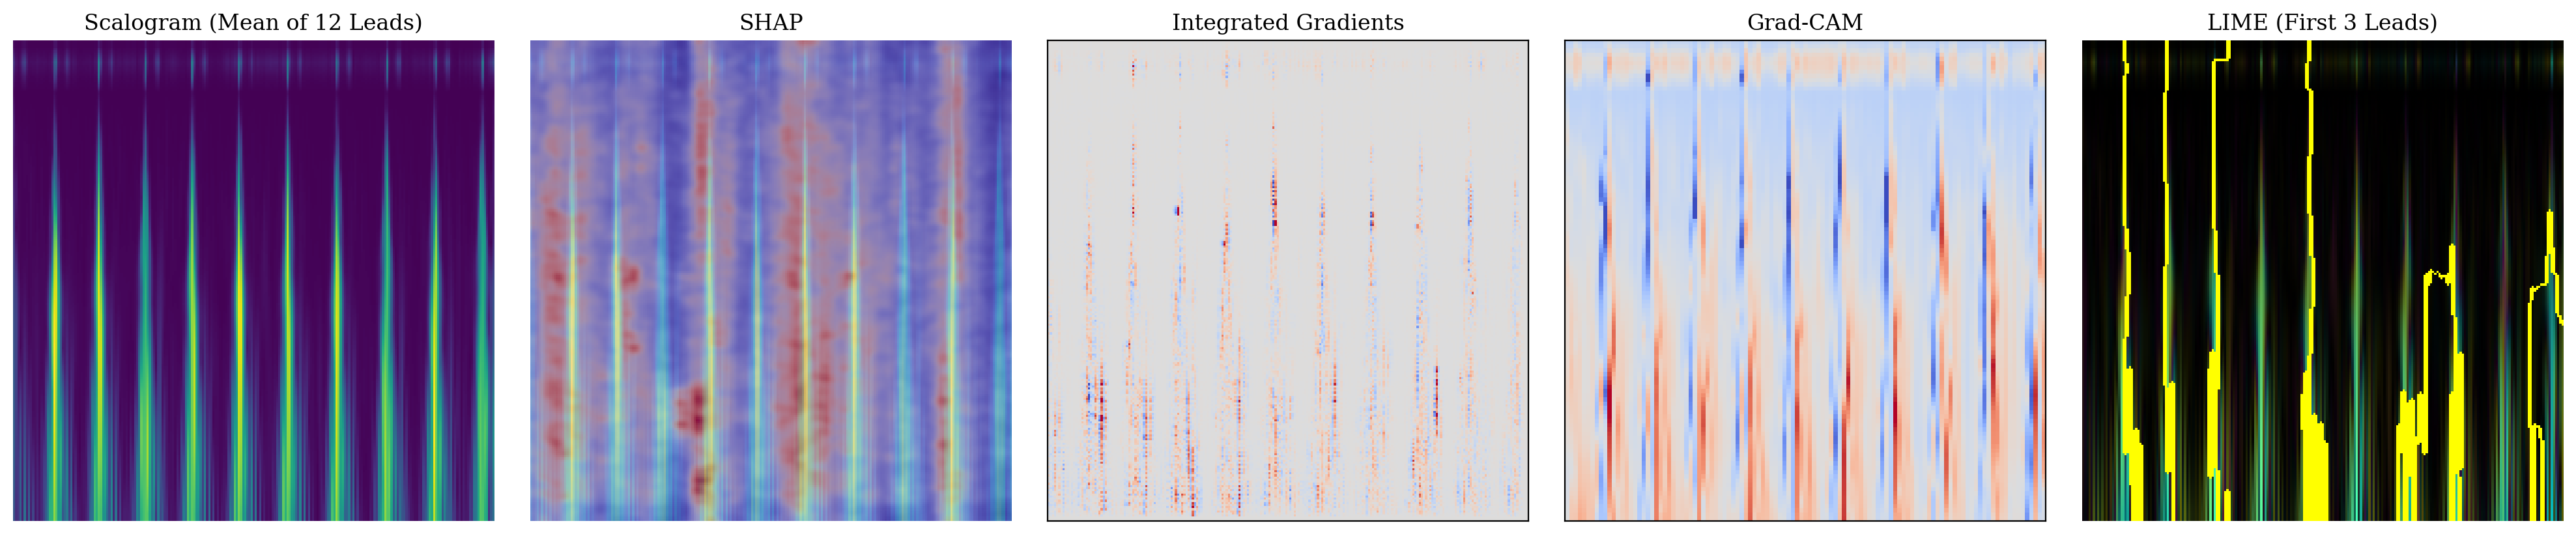

In [56]:
import matplotlib.pyplot as plt
import numpy as np
from captum.attr import visualization as viz
from skimage.segmentation import mark_boundaries
from scipy.ndimage import gaussian_filter

def visualize_explanations(img_tensor, shap_vals, ig_attr, gc_attr, lime_exp):
    # 1. Base Image (Mean of 12 Leads)
    img_2d_single = img_tensor[0].mean(dim=0).cpu().detach().numpy()
    img_disp = (img_2d_single - img_2d_single.min()) / (img_2d_single.max() - img_2d_single.min() + 1e-8)

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))

    # 0. Base Image
    axes[0].imshow(img_disp, cmap='viridis')
    axes[0].set_title("Scalogram (Mean of 12 Leads)")
    axes[0].axis('off')

    # 1. SHAP
    sv = shap_vals[0] if isinstance(shap_vals, list) else shap_vals
    sh_arr = np.array(sv).reshape(-1, 12, 227, 227)
    shap_sum = np.sum(np.abs(sh_arr[0]), axis=0)
    shap_sum = gaussian_filter(shap_sum, sigma=2) # Smooth out the static

    axes[1].imshow(img_disp, cmap='viridis') # Plot base scalogram
    axes[1].imshow(shap_sum, cmap='coolwarm', alpha=0.6) # Overlay SHAP
    axes[1].set_title("SHAP")
    axes[1].axis('off')

# 2. Integrated Gradients
    img_disp_captum = np.expand_dims(img_disp, axis=-1)
    ig_attr_sum = ig_attr[0].sum(dim=0).unsqueeze(-1).cpu().detach().numpy()

    viz.visualize_image_attr(
        ig_attr_sum, img_disp_captum,
        method="heat_map",   # <-- CHANGED: Removes the gray background washout
        sign="all",
        cmap="coolwarm",
        outlier_perc=2,
        plt_fig_axis=(fig, axes[2]),
        use_pyplot=False
    )
    axes[2].set_title("Integrated Gradients")

    # 3. Grad-CAM
    gc_attr_sum = gc_attr[0].sum(dim=0).unsqueeze(-1).cpu().detach().numpy()

    viz.visualize_image_attr(
        gc_attr_sum, img_disp_captum,
        method="heat_map",   # <-- CHANGED: Removes the gray background washout
        sign="all",
        cmap="coolwarm",
        outlier_perc=2,
        plt_fig_axis=(fig, axes[3]),
        use_pyplot=False
    )
    axes[3].set_title("Grad-CAM")

    # 4. LIME
    temp, mask = lime_exp.get_image_and_mask(lime_exp.top_labels[0], positive_only=True, num_features=5, hide_rest=False)
    temp_disp = (temp - temp.min()) / (temp.max() - temp.min() + 1e-8)
    axes[4].imshow(mark_boundaries(temp_disp, mask))
    axes[4].set_title("LIME (First 3 Leads)")
    axes[4].axis('off')

    plt.tight_layout()
    plt.show()


visualize_explanations(img_2d, shap_vals, ig_attr, gc_attr, lime_exp)

# Model 3: Self-Attention-Based Autoencoder (AE)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score
from captum.attr import IntegratedGradients, GradientShap, LayerGradCam, Lime

class PreloadedECGDataset(Dataset):
    def __init__(self, X, y):
        # Extract 1st lead as per paper & transpose from (N, 1000, 12) -> (N, 1, 1000)
        self.X = torch.tensor(X[:, :, 0:1].transpose(0, 2, 1), dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # 50/60Hz PLI filtering omitted: Nyquist limit for 100Hz data is 50Hz.
        return self.X[idx], self.y[idx]

class SelfAttentionAEClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.lstm1 = nn.LSTM(1, 128, batch_first=True)
        self.pool = nn.MaxPool1d(kernel_size=3)
        self.lstm2 = nn.LSTM(128, 64, batch_first=True)
        self.lstm3 = nn.LSTM(64, 64, batch_first=True)
        self.lstm4 = nn.LSTM(64, 128, batch_first=True)
        self.attn_qkv = nn.Linear(128, 128 * 3)
        self.gradcam_hook = nn.Identity()
        self.classifier = nn.Sequential(
            nn.Linear(128, 45),
            nn.ReLU(),
            nn.Linear(45, num_classes)
        )

    def forward(self, x):
        x = x.transpose(1, 2)
        x, _ = self.lstm1(x)
        x = self.pool(x.transpose(1, 2)).transpose(1, 2)
        x, _ = self.lstm2(x)
        x, _ = self.lstm3(x)
        x, _ = self.lstm4(x)

        q, k, v = self.attn_qkv(x).chunk(3, dim=-1)
        attn_weights = torch.softmax(torch.bmm(q, k.transpose(1, 2)) / (128 ** 0.5), dim=-1)
        x = torch.bmm(attn_weights, v)

        x = self.gradcam_hook(x.transpose(1, 2))
        x = x[:, :, -1]
        return self.classifier(x)

def train_and_validate(model, train_loader, val_loader, epochs=1, lr=1e-3, device='cuda'):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in tqdm(range(epochs)):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                preds = torch.sigmoid(model(X_batch)).cpu().numpy()
                all_preds.append(preds)
                all_labels.append(y_batch.numpy())

        all_preds = np.vstack(all_preds)
        all_labels = np.vstack(all_labels)

        auc = roc_auc_score(all_labels, all_preds, average='macro')
        f1 = f1_score(all_labels, (all_preds > 0.5).astype(int), average='macro')
        print(f"Epoch {epoch+1}/{epochs} - Macro AUC: {auc:.4f}, Macro F1: {f1:.4f}")



train_ds = PreloadedECGDataset(X_train, y_train)
val_ds = PreloadedECGDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

num_classes = y_train.shape[1]
model = SelfAttentionAEClassifier(num_classes=num_classes)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_and_validate(model, train_loader, val_loader, epochs=5, device=device)

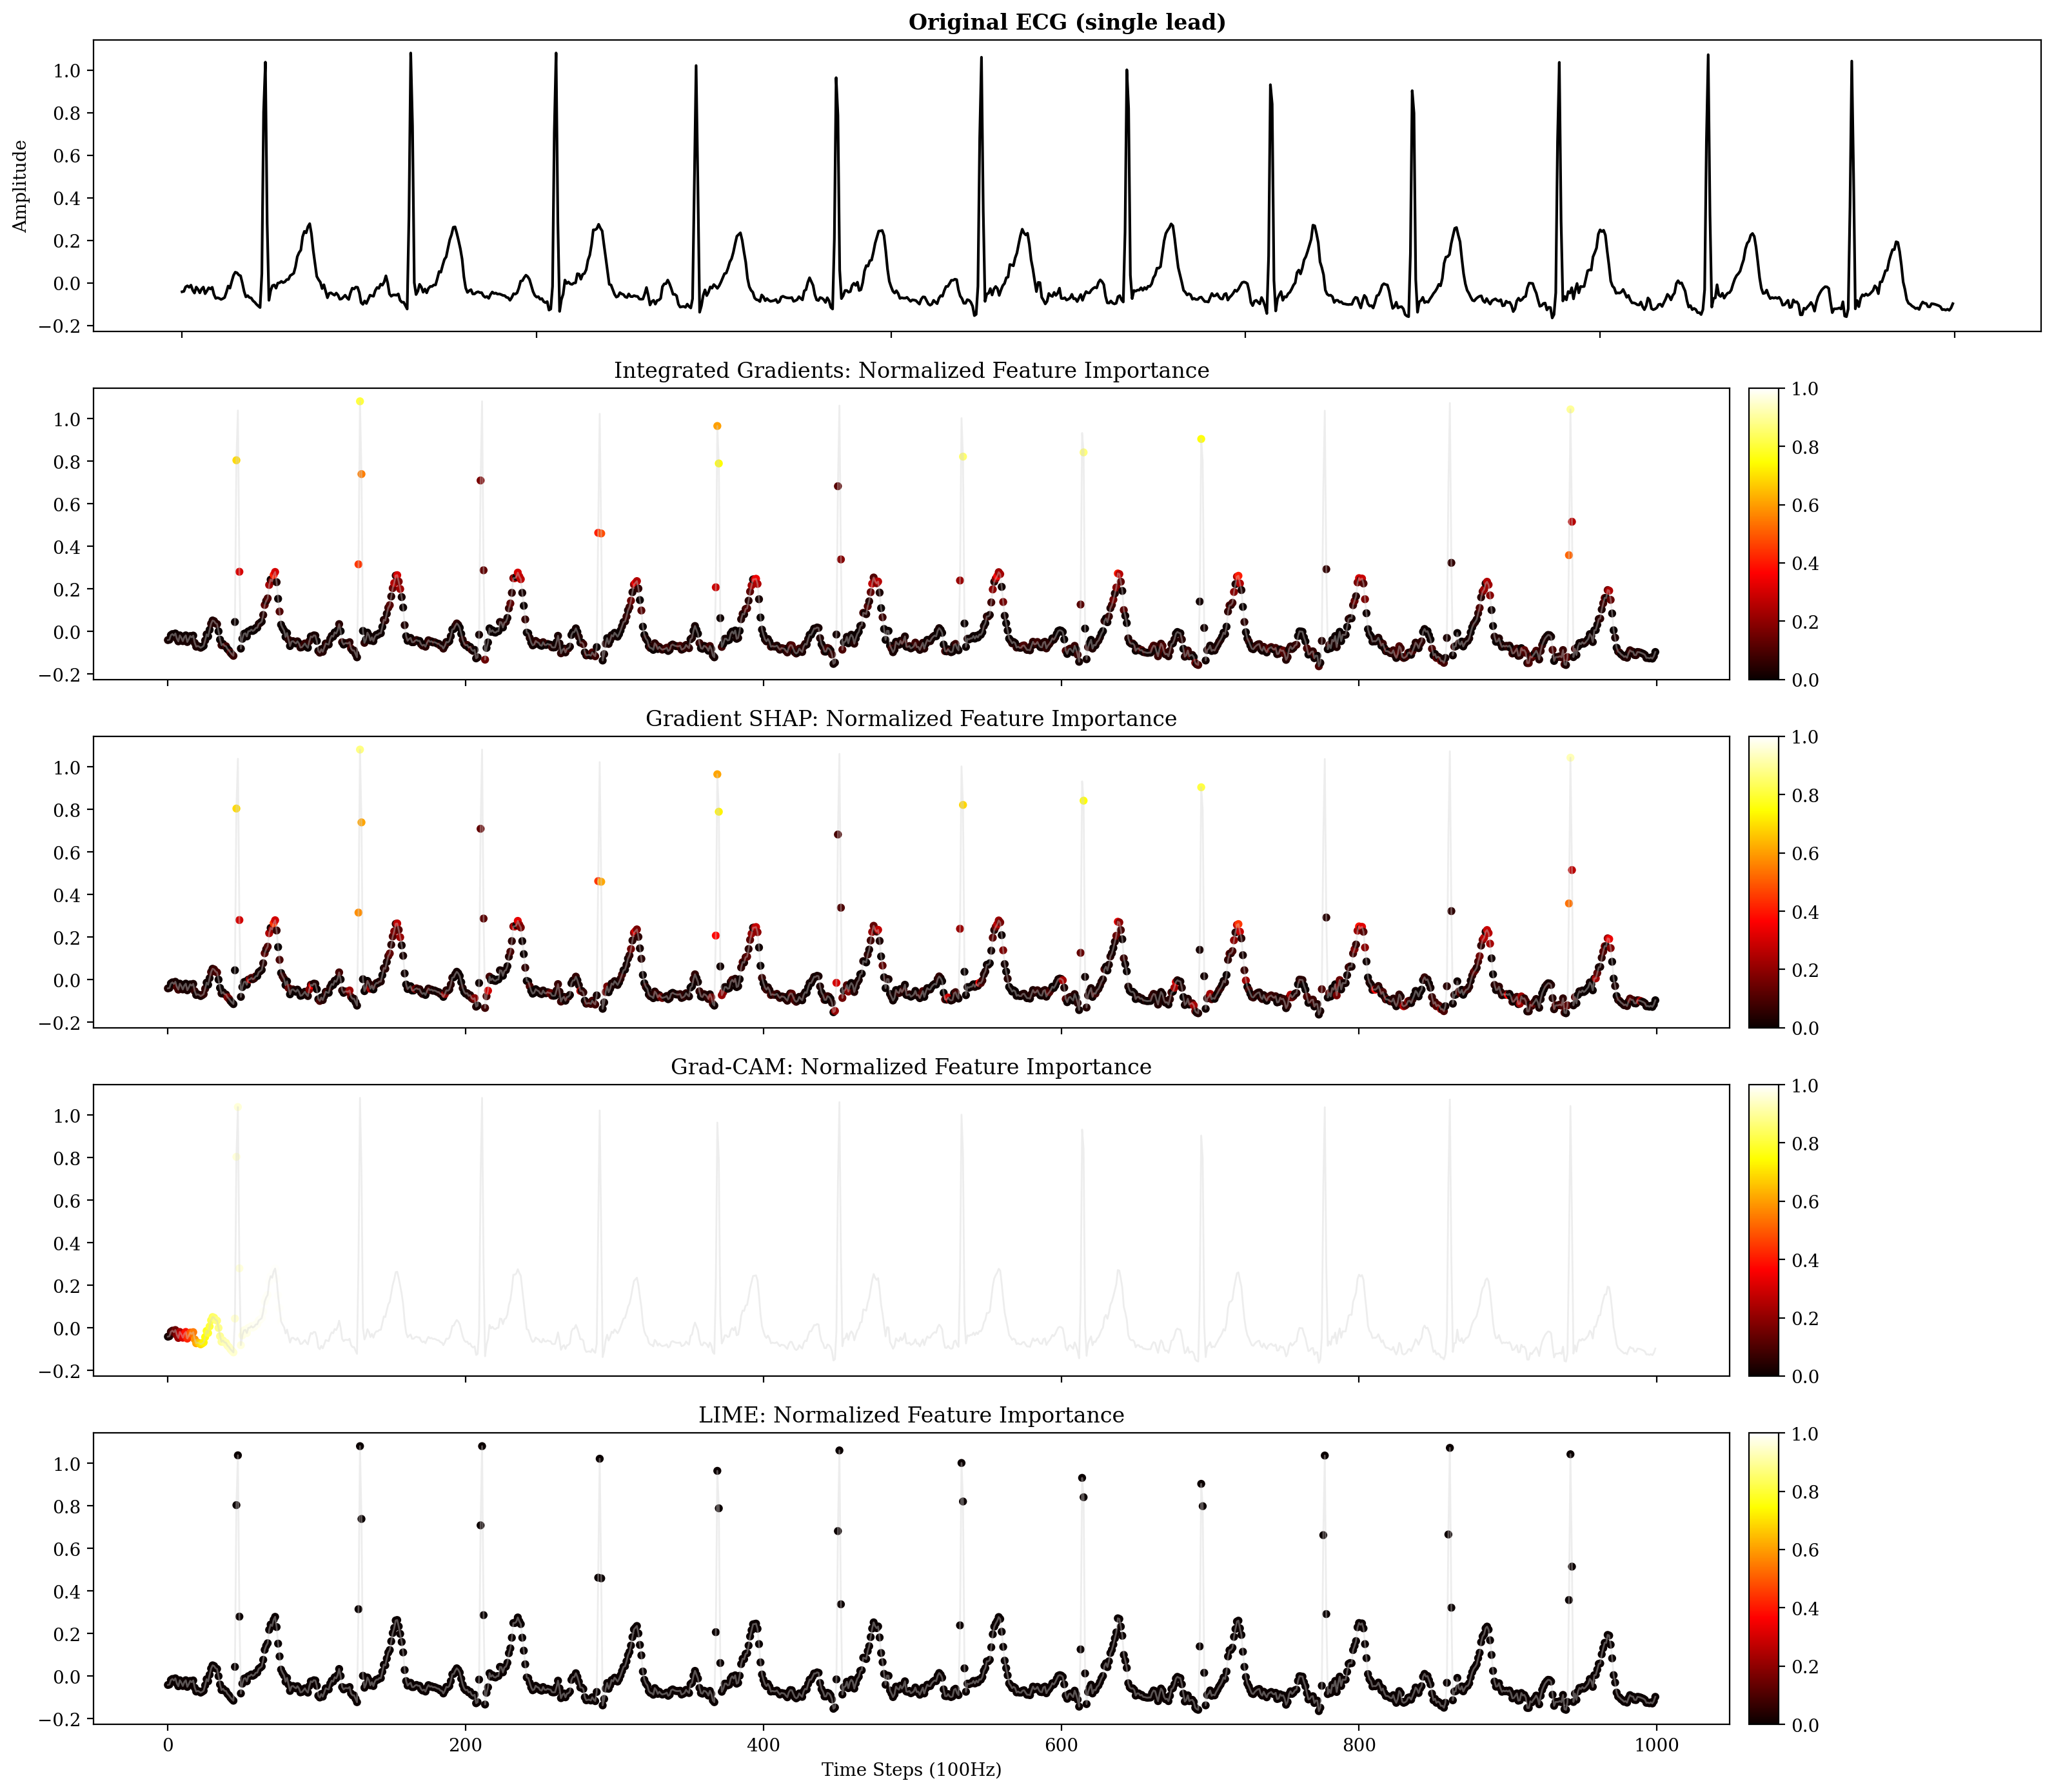

In [66]:
import matplotlib.pyplot as plt
import numpy as np


def visualize_XAI(sample_x, ig_attr, shap_attr, gc_attr, lime_attr):
    signal = sample_x.squeeze().cpu().detach().numpy()
    t = np.arange(len(signal))

    def robust_rescale(attr_raw):
        a = attr_raw.squeeze().cpu().detach().numpy()
        if len(a) != len(signal):
            a = np.interp(t, np.linspace(0, len(signal)-1, len(a)), a)
        a = np.abs(a)
        v_max = np.percentile(a, 99)
        v_min = np.min(a)
        if v_max > v_min:
            a = np.clip((a - v_min) / (v_max - v_min), 0, 1)
        else:
            a = np.zeros_like(a)
        return a

    attrs = {
        "Integrated Gradients": robust_rescale(ig_attr),
        "Gradient SHAP": robust_rescale(shap_attr),
        "Grad-CAM": robust_rescale(gc_attr),
        "LIME": robust_rescale(lime_attr)
    }

    fig, axes = plt.subplots(5, 1, figsize=(16, 14), sharex=True)
    axes[0].plot(t, signal, color='black', lw=1.5)
    axes[0].set_title("Original ECG (single lead)", fontweight='bold')
    axes[0].set_ylabel("Amplitude")

    for i, (name, data) in enumerate(attrs.items(), 1):
        axes[i].plot(t, signal, color='lightgray', alpha=0.4, lw=1)
        sc = axes[i].scatter(t, signal, c=data, cmap='hot', s=12, vmin=0, vmax=1)
        axes[i].set_title(f"{name}: Normalized Feature Importance")
        plt.colorbar(sc, ax=axes[i], aspect=10, pad=0.01)

    axes[-1].set_xlabel("Time Steps (100Hz)")
    plt.tight_layout()
    plt.show()


sample_x, _ = val_ds[0]
ig, shap, gcam, lime = run_xai_pipeline(model, sample_x, target_class=0, device=device)

visualize_XAI(sample_x, ig, shap, gcam, lime)